# Assignment 4: Feature points, matching, homography

## Exercise 1: Feature points detectors

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import random
from ipywidgets import interact, IntSlider, FloatSlider
import a4_utils as a4
import matplotlib
%matplotlib inline

### 1a)

In [3]:
def der_x(image, sigma):
    image = image.astype(np.float64)
    d = a4.gaussdx(sigma)
    g = a4.gauss(sigma)

    return a4.convolve(image, g.T, d)


def der_y(image, sigma):
    image = image.astype(np.float64)
    d = a4.gaussdx(sigma)
    g = a4.gauss(sigma)

    return a4.convolve(image, g, d.T)

def der_xx(image, sigma):
    image = image.astype(np.float64)
    d = a4.gaussdx(sigma)
    g = a4.gauss(sigma)

    return a4.convolve(der_x(image, sigma), g.T, d)

def der_yy(image, sigma):
    image = image.astype(np.float64)
    d = a4.gaussdx(sigma)
    g = a4.gauss(sigma)

    return a4.convolve(der_y(image, sigma), g, d.T)

def der_xy(image, sigma):
    image = image.astype(np.float64)
    d = a4.gaussdx(sigma)
    g = a4.gauss(sigma)

    return a4.convolve(der_x(image, sigma), g, d.T)

def nonmaxima_suppression_box(img, k=3):
    r = k // 2
    h, w = img.shape

    imgh_pad = np.pad(img, r, mode='reflect')
    res = np.zeros_like(img)

    for y in range(h):
        for x in range(w):
            window = imgh_pad[y : y + 2*r + 1, x : x + 2*r + 1]
            center = img[y, x]

            if center == 0:
                continue

            vals = window[window > 0]
            if vals.size == 0:
                continue

            maxval = np.max(vals)

            if center == maxval:
                res[y, x] = center

    return res

1a)

In [4]:
def hessian_points(image, sigma, threshold):
    Ixx = der_xx(image, sigma)
    Iyy = der_yy(image, sigma)
    Ixy = der_xy(image, sigma)

    detH = Ixx * Iyy - Ixy**2
    detH_norm = (detH - detH.min()) / (detH.max() - detH.min())
    detH_norm = np.where(detH_norm > threshold, detH_norm, 0)
    detH_nms = nonmaxima_suppression_box(detH_norm)

    return detH, np.nonzero(detH_nms)

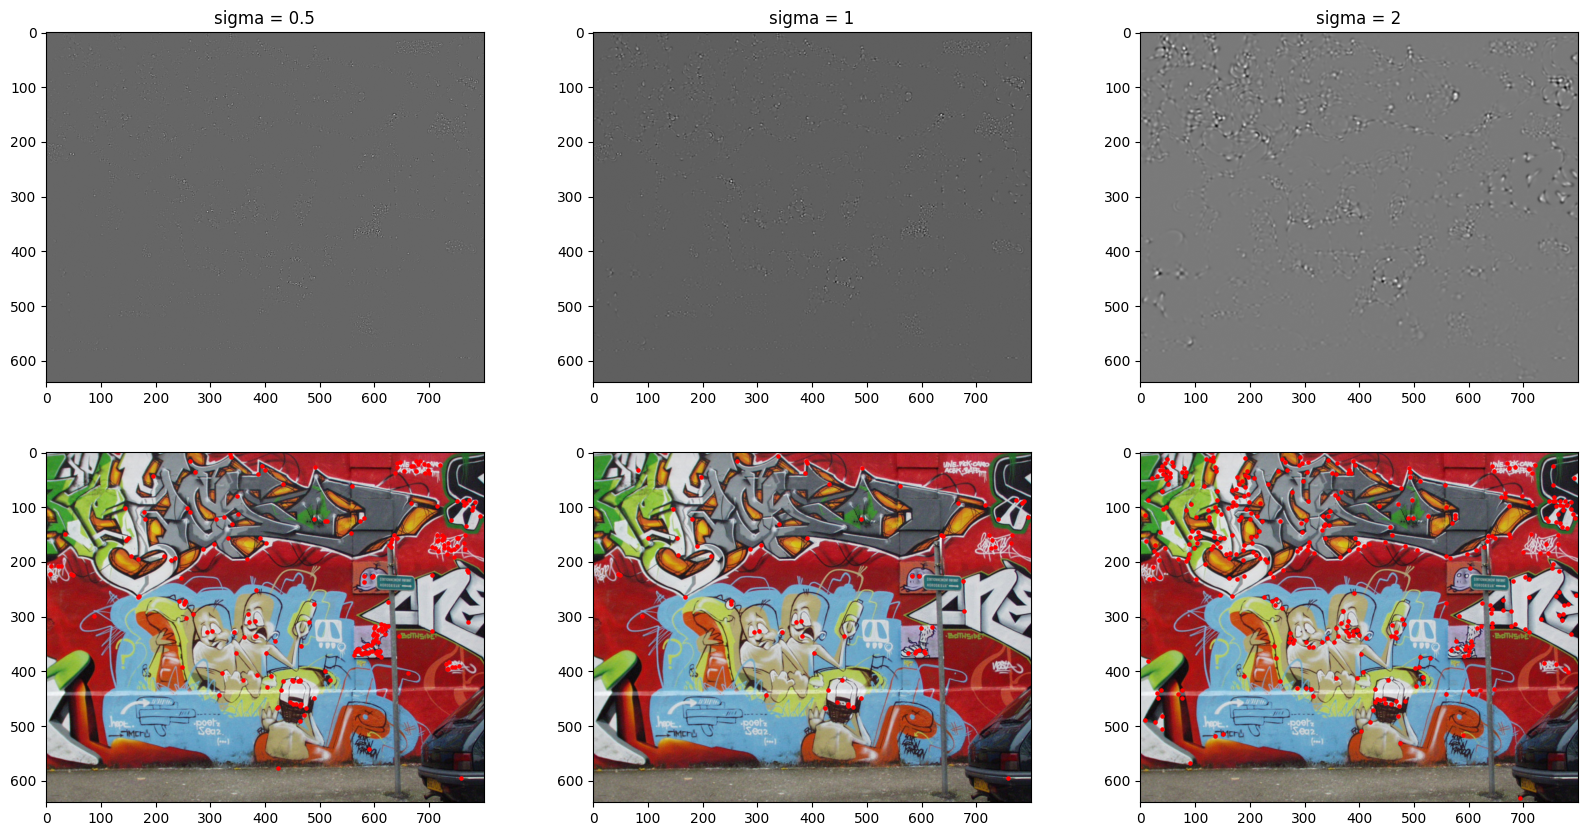

In [5]:
graf_a = cv2.imread('./data/graf/graf_a.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
graf_a_color = cv2.cvtColor(cv2.imread('./data/graf/graf_a.jpg'), cv2.COLOR_BGR2RGB)
sigmas = [0.5, 1, 2]

fig, plot = plt.subplots(2, len(sigmas), figsize=(20,10))

for i in range(len(sigmas)):
    deth, keypoints = hessian_points(graf_a, sigmas[i], threshold=0.60)

    plot[0,i].imshow(deth, cmap='gray')
    plot[0,i].set_title(f"sigma = {sigmas[i]}")

    plot[1,i].imshow(graf_a_color)
    plot[1,i].scatter(keypoints[1], keypoints[0], c='r', s=5)

plt.show()


**Question: What kind of structures in the image are detected by the algorithm? How does the parameter σ affect the result?**
The algorithm detects blob like structures in practice corners, bright/dark spots. Small σ detects fine details, while a large σ extracts only large-scale features.

In [26]:
# def slider():
#     @interact(
#         sigma = FloatSlider(min=0.0, max=5, step=0.5, value=3),
#         threshold = FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5)
#     )
#     def show_hessian(sigma, threshold):
#         detH_norm, (ys, xs) = hessian_points(graf_a, sigma, threshold)
#         plt.figure(figsize=(14,6))
#
#         plt.subplot(1,2,1)
#         plt.imshow(detH_norm, cmap='gray')
#         plt.title(f"detH_norm  (sigma={sigma}, thresh={threshold})")
#         plt.colorbar()
#
#         plt.subplot(1,2,2)
#         plt.imshow(graf_a, cmap='gray')
#         plt.scatter(xs, ys, c='red', s=5)
#         plt.title(f"{len(xs)} points detected")
#
#         plt.show()

In [27]:
# slider()

### 1b)

In [8]:
def harris_points(image, sigma, threshold):
    sigma_ = 1.6 * sigma
    alpha = 0.06
    Ix = der_x(image, sigma)
    Ix2 = Ix * Ix
    Iy = der_y(image, sigma)
    Iy2 = Iy * Iy
    Ixy = Ix * Iy

    G = a4.gauss(sigma_)
    C11 = a4.convolve(Ix2, G.T, G)
    C12 = a4.convolve(Ixy, G.T, G)
    C22 = a4.convolve(Iy2, G.T, G)

    detC = C11*C22 - C12**2
    traceC = C11 + C22

    condition = detC - alpha * (traceC ** 2)
    harris = np.where(condition > threshold, condition, 0)
    keypoints = nonmaxima_suppression_box(harris)
    return condition, np.nonzero(keypoints)

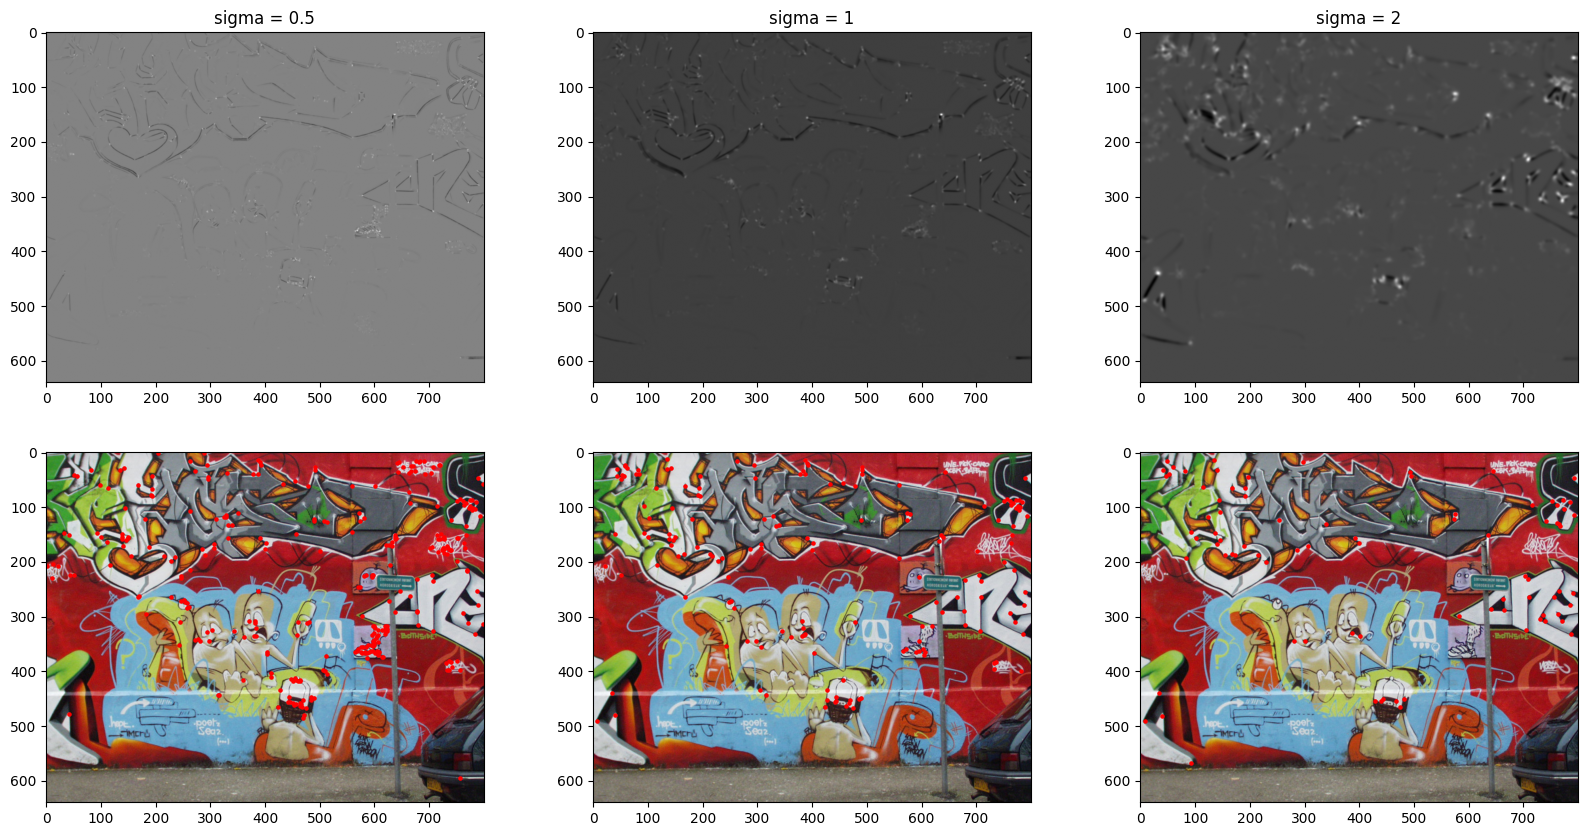

In [9]:
graf_a = cv2.imread('./data/graf/graf_a.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
graf_a_color = cv2.cvtColor(cv2.imread('./data/graf/graf_a.jpg'), cv2.COLOR_BGR2RGB)
sigmas = [0.5, 1, 2]

fig, plot = plt.subplots(2, len(sigmas), figsize=(20,10))

for i in range(len(sigmas)):
    condition, keypoints = harris_points(graf_a, sigmas[i], threshold=1e-4)

    plot[0,i].imshow(condition, cmap='gray')
    plot[0,i].set_title(f"sigma = {sigmas[i]}")

    plot[1,i].imshow(graf_a_color)
    plot[1,i].scatter(keypoints[1], keypoints[0], c='r', s=5)

plt.show()


## Exercise 2: Matching local regions

### 2a)

In [10]:
def hellinger_dist(h1, h2):
    return np.sqrt(np.sum((np.sqrt(h1) - np.sqrt(h2))**2)/2)

def find_correspondences(descriptors1, descriptors2):
    correspondences = []

    for i in range(len(descriptors1)):
        desc1 = descriptors1[i]

        min_dist = float('inf')
        min_j = None

        for j in range(len(descriptors2)):
            desc2 = descriptors2[j]

            dist = hellinger_dist(desc1, desc2)

            if dist < min_dist:
                min_dist = dist
                min_j = j

        correspondences.append([i, min_j])

    return np.array(correspondences)


In [11]:
def task_2a():
    graf_a_small = cv2.imread('./data/graf/graf_a_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
    graf_b_small = cv2.imread('./data/graf/graf_b_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0

    # _, keypoints1 = harris_points(graf_a_small, sigma = 0.5, threshold=1e-4)
    # _, keypoints2 = harris_points(graf_b_small, sigma = 0.5, threshold=1e-4)

    _, keypoints1 = hessian_points(graf_a_small, sigma = 9, threshold=0.6)
    _, keypoints2 = hessian_points(graf_b_small, sigma = 9, threshold=0.6)

    descriptors1 = a4.simple_descriptors(graf_a_small, keypoints1[0], keypoints1[1], n_bins=16, window_size=20)
    descriptors2 = a4.simple_descriptors(graf_b_small, keypoints2[0], keypoints2[1], n_bins=16, window_size=20)

    correspondences = find_correspondences(descriptors1, descriptors2)
    points1, points2 = [], []
    points1 = np.column_stack((keypoints1[1], keypoints1[0]))   # (x, y)
    points2 = np.column_stack((keypoints2[1], keypoints2[0]))   # (x, y)

    a4.display_matches(graf_a_small, graf_b_small, np.array(points1), np.array(points2), correspondences)
    return

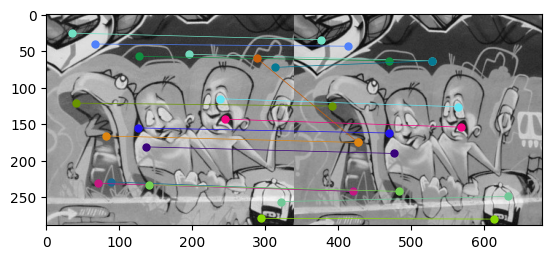

In [12]:
# matplotlib.use('TkAgg')
task_2a()

In [13]:
# %matplotlib inline

2b)

In [14]:
def find_matches(img1, img2, detector = 'harris'):
    keypoints1, keypoints2 = [], []
    if(detector == 'harris'):
        _, keypoints1 = harris_points(img1, sigma = 0.5, threshold=1e-4)
        _, keypoints2 = harris_points(img2, sigma = 0.5, threshold=1e-4)
    elif(detector == 'hessian'):
        _, keypoints1 = hessian_points(img1, sigma = 9, threshold=0.6)
        _, keypoints2 = hessian_points(img2, sigma = 9, threshold=0.6)

    descriptors1 = a4.simple_descriptors(img1, keypoints1[0], keypoints1[1], n_bins=16, window_size=20)
    descriptors2 = a4.simple_descriptors(img2, keypoints2[0], keypoints2[1], n_bins=16, window_size=20)

    matches1 = find_correspondences(descriptors1, descriptors2)
    matches2 = find_correspondences(descriptors2, descriptors1)

    points1 = np.column_stack((keypoints1[1], keypoints1[0]))
    points2 = np.column_stack((keypoints2[1], keypoints2[0]))

    reverse_map = {j: i for j, i in matches2}
    symetric = []

    for i,j in matches1:
        if j in reverse_map and reverse_map[j] == i:
            symetric.append([i,j])

    a4.display_matches(img1, img2, np.array(points1), np.array(points2), symetric)

    return np.array(points1), np.array(points2), np.array(symetric)

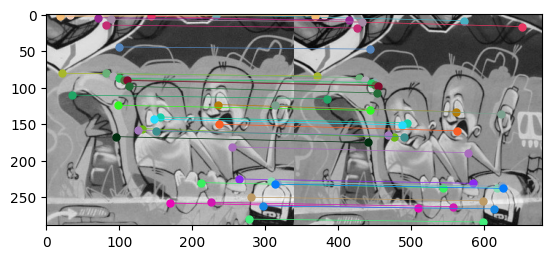

In [15]:
graf_a_small = cv2.imread('./data/graf/graf_a_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
graf_b_small = cv2.imread('./data/graf/graf_b_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
_, _, _ = find_matches(graf_a_small, graf_b_small)

**Question: What do you notice when visualizing the correspondences? How accurate are the matches?**
The correspondences are much better, the matches are perfect.

2c)

In [16]:
def brief(img, keypoints, patch_size=31, n_pairs=256):
    descriptors = []
    half = patch_size // 2
    padded_img = np.pad(img, ((half, half), (half, half)), 'reflect')

    pairs = []
    random.seed(0)

    for i in range(n_pairs):
        x1 = random.randint(- half, half)
        y1 = random.randint(- half, half)
        x2 = random.randint(- half, half)
        y2 = random.randint(- half, half)
        pairs.append([x1, y1, x2, y2])

    for y, x in zip(keypoints[0], keypoints[1]):
        bits = []
        px = x + half
        py = y + half
        patch = padded_img[py - half : py + half + 1, px - half : px + half + 1]

        for x1, y1, x2, y2 in pairs:
            px1 = x1 + half
            py1 = y1 + half
            px2 = x2 + half
            py2 = y2 + half

            I1 = patch[py1, px1]
            I2 = patch[py2, px2]

            if(I1 < I2):
                bits.append(1)
            else:
                bits.append(0)

        descriptors.append(bits)

    return np.array(descriptors)

def hamming_dist(d1, d2):
    dist = 0
    for i in range(len(d1)):
        if d1[i] != d2[i]:
            dist += 1
    return dist

def find_correspondences_Hamming(descriptors1, descriptors2):
    correspondences = []

    for i in range(len(descriptors1)):
        desc1 = descriptors1[i]

        min_dist = float('inf')
        min_j = None

        for j in range(len(descriptors2)):
            desc2 = descriptors2[j]

            dist = hamming_dist(desc1, desc2)

            if dist < min_dist:
                min_dist = dist
                min_j = j

        correspondences.append([i, min_j])

    return np.array(correspondences)

In [17]:
def find_matches_brief(img1, img2, detector = 'harris'):
    keypoints1, keypoints2 = [], []
    if(detector == 'harris'):
        _, keypoints1 = harris_points(img1, sigma = 0.5, threshold=1e-4)
        _, keypoints2 = harris_points(img2, sigma = 0.5, threshold=1e-4)
    elif(detector == 'hessian'):
        _, keypoints1 = hessian_points(img1, sigma = 9, threshold=0.6)
        _, keypoints2 = hessian_points(img2, sigma = 9, threshold=0.6)


    descriptors1 = brief(graf_a_small, keypoints1)
    descriptors2 =  brief(graf_b_small, keypoints2)
    matches1 = find_correspondences_Hamming(descriptors1, descriptors2)
    matches2 = find_correspondences_Hamming(descriptors2, descriptors1)

    points1 = np.column_stack((keypoints1[1], keypoints1[0]))
    points2 = np.column_stack((keypoints2[1], keypoints2[0]))

    reverse_map = {j: i for j, i in matches2}
    symetric = []

    for i,j in matches1:
        if j in reverse_map and reverse_map[j] == i:
            symetric.append([i,j])

    a4.display_matches(img1, img2, np.array(points1), np.array(points2), symetric)
    return np.array(symetric)

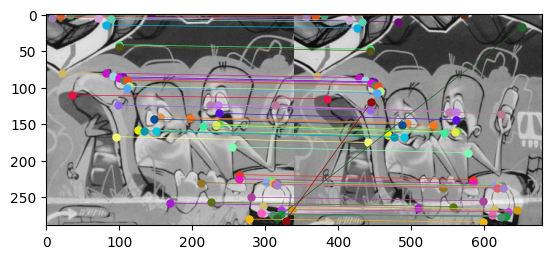

In [18]:
graf_a_small = cv2.imread('./data/graf/graf_a_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
graf_b_small = cv2.imread('./data/graf/graf_b_small.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
_ = find_matches_brief(graf_a_small, graf_b_small)

## Exercise 3: Homography estimation

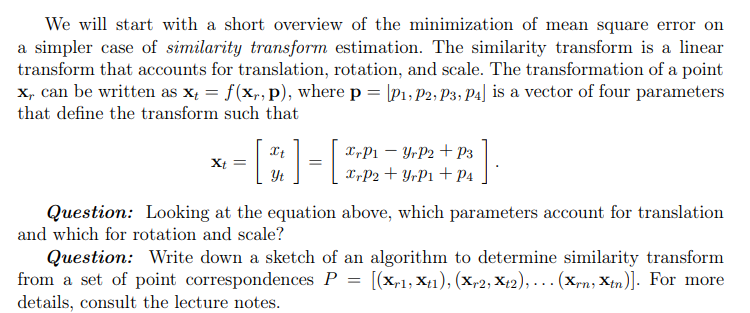

Parameter p₃ represents translation in the x-direction and p₄ translation in the y-direction.
The parameters $p_1$ and $p_2$ represent rotation and scale, since together they form a matrix
\begin{bmatrix}
p_1 & -p_2 \\
-p_2 & p_1
\end{bmatrix}
which is equivalent to a rotation matrix multiplied by a uniform scale factor.



3a)

In [19]:
def estimate_homography(pointsr, pointst):
    A = np.zeros((2*len(pointsr), 9))
    i = 0
    for ((xr, yr), (xt, yt)) in zip(pointsr, pointst):
        A[i] = np.array([xr, yr, 1, 0, 0, 0, -xt*xr, -xt*yr, -xt])
        A[i+1] = np.array([0, 0, 0, xr, yr, 1, -yt*xr, -yt*yr, -yt])
        i += 2

    _, _, VT = np.linalg.svd(A)
    h = VT[-1, :]
    H = (h / h[-1]).reshape(3, 3)

    return H

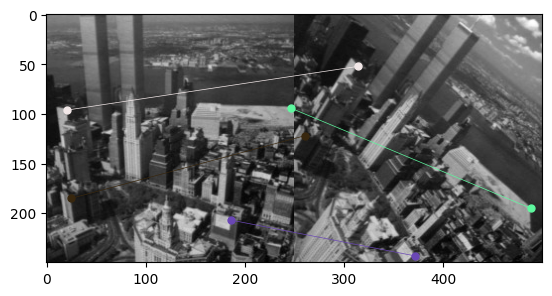

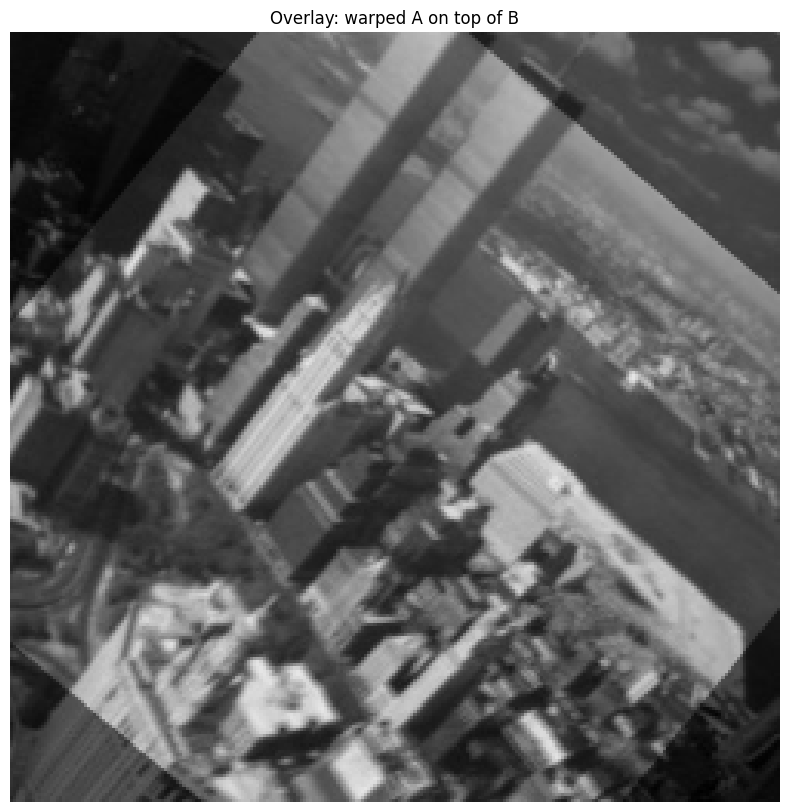

In [20]:
newyork_a = cv2.imread('./data/newyork/newyork_a.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
newyork_b = cv2.imread('./data/newyork/newyork_b.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
pairs = np.loadtxt('./data/newyork/newyork.txt')
pointsr = pairs[:, :2]
pointst = pairs[:, 2:]

matches = np.array([[i, i] for i in range(len(pairs))])
a4.display_matches(newyork_a, newyork_b, pointsr, pointst, matches)

H = estimate_homography(pointsr, pointst)
# print(H)
h2, w2 = newyork_b.shape
warped = cv2.warpPerspective(newyork_a, H, (w2, h2))
plt.figure(figsize=(10,10))

plt.imshow(newyork_b, cmap='gray')
plt.imshow(warped, cmap='gray', alpha=0.5)
plt.title("Overlay: warped A on top of B")
plt.axis('off')

plt.show()


In [21]:
# graf_a = cv2.imread('./data/graf/graf_a.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
# graf_b = cv2.imread('./data/graf/graf_b.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255.0
# pairs = np.loadtxt('./data/graf/graf.txt')
# pointsr = pairs[:, :2]
# pointst = pairs[:, 2:]
#
# matches = np.array([[i, i] for i in range(len(pairs))])
# a4.display_matches(graf_a, graf_b, pointsr, pointst, matches)
#
# H = estimate_homography(pointsr, pointst)
# # print(H)
# h2, w2 = graf_b.shape
# warped = cv2.warpPerspective(graf_a, H, (w2, h2))
# plt.figure(figsize=(10,10))
#
# plt.imshow(graf_b, cmap='gray')
# plt.imshow(warped, cmap='gray', alpha=0.5)
# plt.axis('off')
#
# plt.show()


3c)

In [22]:
def find_matches2(img1, img2, detector = 'harris'):
    keypoints1, keypoints2 = [], []

    _, keypoints1 = hessian_points(img1, sigma=3, threshold=0.01)
    _, keypoints2 = hessian_points(img2, sigma=3, threshold=0.01)


    descriptors1 = a4.simple_descriptors(img1, keypoints1[0], keypoints1[1], n_bins=16, window_size=20)
    descriptors2 = a4.simple_descriptors(img2, keypoints2[0], keypoints2[1], n_bins=16, window_size=20)

    matches1 = find_correspondences(descriptors1, descriptors2)
    matches2 = find_correspondences(descriptors2, descriptors1)

    points1 = np.column_stack((keypoints1[1], keypoints1[0]))
    points2 = np.column_stack((keypoints2[1], keypoints2[0]))

    reverse_map = {j: i for j, i in matches2}
    symetric = []

    for i,j in matches1:
        if j in reverse_map and reverse_map[j] == i:
            symetric.append([i,j])


    return np.array(points1), np.array(points2), np.array(symetric)

In [23]:
def reprojection_error(H, points1, points2):
    points1 = np.asarray(points1)
    points2 = np.asarray(points2)

    pts1_h = np.hstack([points1, np.ones((len(points1), 1))])
    proj = (H @ pts1_h.T).T
    proj = proj[:, :2] / proj[:, 2:3]

    errors = np.linalg.norm(proj - points2, axis=1)

    return errors


In [24]:
def ransac(points1, points2, max_iters = 2000, threshold=3.0):
    best_H = None
    max_inliers = None
    max_num_inliers = 0

    for _ in range(max_iters):
        idx = np.random.choice(len(points1), 4, replace=False)
        subset1 = points1[idx]
        subset2 = points2[idx]

        H = estimate_homography(subset1, subset2)

        errors = reprojection_error(H, points1, points2)
        inliers = errors < threshold
        num_inliers = np.sum(inliers)

        if(num_inliers > max_num_inliers):
            max_num_inliers = num_inliers
            max_inliers = inliers
            best_H = H

    if max_inliers is not None:
        final_H = estimate_homography(points1[max_inliers], points2[max_inliers])
    else:
        final_H = best_H

    final_error = np.mean(reprojection_error(final_H, points1[max_inliers], points2[max_inliers]))

    return final_H, max_inliers, final_error

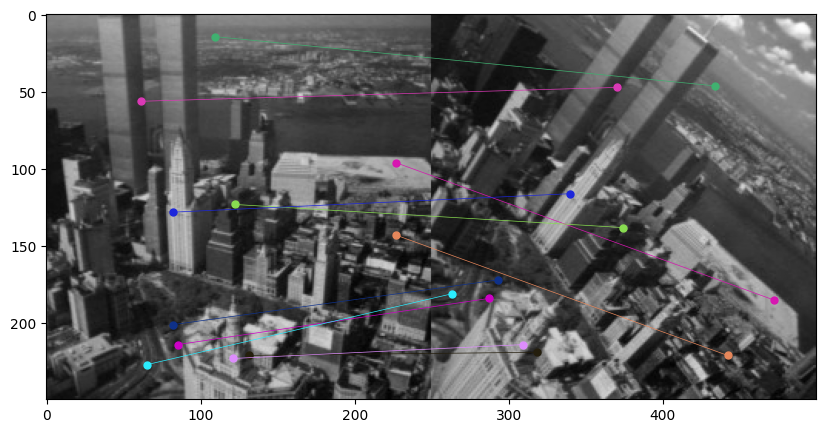

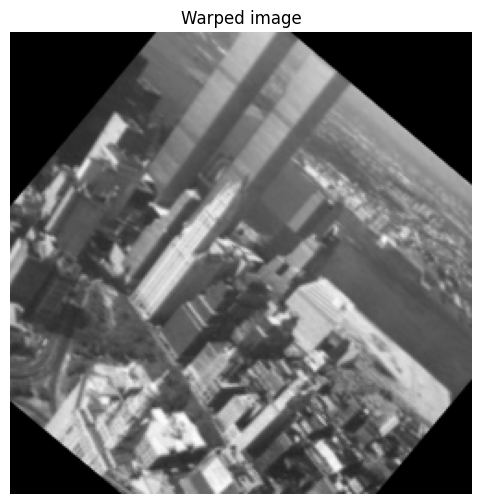

In [25]:
newyork_a = cv2.imread('./data/newyork/newyork_a.jpg', cv2.IMREAD_GRAYSCALE)/255.0
newyork_b = cv2.imread('./data/newyork/newyork_b.jpg', cv2.IMREAD_GRAYSCALE)/255.0

points1_all, points2_all, matches = find_matches2(newyork_a, newyork_b)

pointsr = points1_all[matches[:,0]]
pointst = points2_all[matches[:,1]]

H_ransac, inliers, error = ransac(pointsr, pointst, max_iters=2000, threshold=0.1)

pts1_in = pointsr[inliers]
pts2_in = pointst[inliers]
matches_in = np.array([[i, i] for i in range(len(pts1_in))])

plt.figure(figsize=(10,5))
a4.display_matches(newyork_a, newyork_b, pts1_in, pts2_in, matches_in)

h2, w2 = newyork_b.shape
warped = cv2.warpPerspective(newyork_a, H_ransac, (w2, h2))

plt.figure(figsize=(6,6))
plt.imshow(warped, cmap='gray')
plt.title("Warped image")
plt.axis('off')
plt.show()